<a href="https://colab.research.google.com/github/SathyaPrakashD/ml-pipeline-fundamentals/blob/main/10_titanic_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction — Classification with Mixed Data

## Objective
Predict whether a Titanic passenger survived or died based on demographic
and ticket information.

## Dataset
- Source: Titanic passenger manifest
- 891 passengers, 8 features after cleaning
- Mixed data: numeric (Age, Fare, Pclass) + categorical (Sex, Embarked)
- Target: Survived (1 = Yes, 0 = No)

## Key Challenges
- Missing values: Age (177), Embarked (2) — handled via imputation
- Mixed data types — handled via ColumnTransformer
- Mild class imbalance (62% died, 38% survived) — handled via class_weight='balanced'

## Approach
- EDA: Target distribution, survival rates by Sex, Pclass, and Age
- Imputation: Median for Age, Mode for Embarked
- Pipeline: ColumnTransformer → RandomForestClassifier
- Lead metric: Recall (class 1) — FN cost is highest (survivor declared dead)

## Results
| Metric | Score |
|--------|-------|
| Accuracy | 82% |
| Recall (survived) | 0.76 |
| Precision (survived) | 0.80 |
| F1 (survived) | 0.78 |

## Key Learnings
- class_weight='balanced' improves minority class recall
- Sex is the strongest survival predictor (74% female vs 19% male survival rate)
- ColumnTransformer handles numeric and categorical features in one pipeline
- Recall is the lead metric when FN consequences are severe

#### Data Inspection

In [6]:
import pandas as pd

# Define the URL for the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
# Read the CSV data into a pandas DataFrame
df = pd.read_csv(url)

# Print the shape of the DataFrame (number of rows and columns)
print(df.shape)
# Print the count of each data type in the DataFrame
print(df.dtypes.value_counts())
# Print the count of null values for the top 10 columns with most missing data
print(df.isnull().sum().sort_values(ascending=False).head(10))

(891, 12)
int64      5
object     5
float64    2
Name: count, dtype: int64
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
dtype: int64


There is 891 rows and 12 columns. Out of 12 columns - 7 columns are numeric and 5 are categorical.

Cabin column is almost blank and age column is having 177 rows null.

In [7]:
# Drop columns that are deemed useless for the analysis
df = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

# Confirm the changes by printing the new shape of the DataFrame
print(df.shape)
# Print the count of null values for all columns after dropping some
print(df.isnull().sum().sort_values(ascending=False))

(891, 8)
Age         177
Embarked      2
Pclass        0
Survived      0
Sex           0
SibSp         0
Parch         0
Fare          0
dtype: int64


In [8]:
# Display the first 5 rows of the DataFrame to get a quick overview of the data
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#### EDA

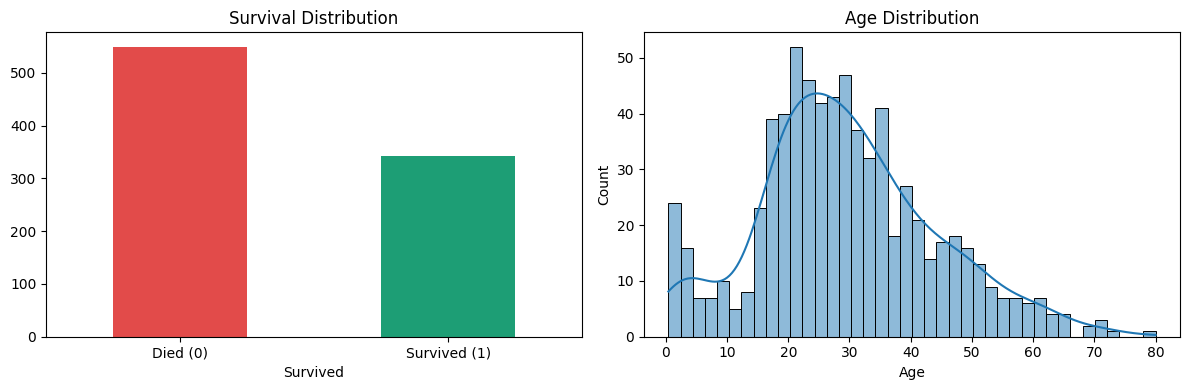

Survived counts:
Survived
0    549
1    342
Name: count, dtype: int64

Age skew: 0.3891


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the distribution of the 'Survived' column (target variable)
# Using a bar plot, with custom colors and labels
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Survival Distribution')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)

# Plot the distribution of the 'Age' column using a histogram with a KDE plot
sns.histplot(df['Age'].dropna(), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
# Display the plots
plt.show()

# Print the counts of survivors and non-survivors
print(f"Survived counts:\n{df['Survived'].value_counts()}")
# Calculate and print the skewness of the 'Age' distribution
print(f"\nAge skew: {df['Age'].skew():.4f}")

In [10]:
# Print the counts of survivors and non-survivors again
print(f"Survived counts:\n{df['Survived'].value_counts()}")
# Print the ratio of survivors and non-survivors, normalized and rounded to 2 decimal places
print(f"Survived ratio: {df['Survived'].value_counts(normalize=True).round(2)}")
# Calculate and print the skewness of the 'Age' distribution again
print(f"\nAge skew: {df['Age'].skew():.4f}")

Survived counts:
Survived
0    549
1    342
Name: count, dtype: int64
Survived ratio: Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Age skew: 0.3891


##### Is Data Balanced ??

Data is like 60, 40 balanced . almost 60 % died and 40% survived. Is my interpretation correct?

21:29
Your observation is correct — 62% died, 38% survived.

But "balanced" is the wrong conclusion.

Balanced means roughly 50/50. Your Wine Quality dataset from Round 4 was severely imbalanced. This is less extreme — but 62/38 is still a mild imbalance, not balanced.

Practical implication:

It's not severe enough to require class_weight='balanced' — but it's worth noting when you interpret your classification report. Your model will naturally see more "died" examples during training.

Rule of thumb to lock:

Ratio	Classification
50/50	Balanced
60/40	Mild imbalance — monitor but may not need fixing
70/30 or worse	Imbalanced — consider class_weight='balanced'

##### age skew = 0.3891 . so mildly skewed

21:33
✅ Correct — skew 0.39 falls in the "roughly symmetric" range.

So technically mean would be acceptable here — the distribution is close enough to normal that mean isn't heavily distorted by outliers.

But here's a practical rule many ML engineers follow:

When in doubt — use median. It's never wrong. Mean is only better when the distribution is confirmed normal.

Skew of 0.39 is borderline. Median is the safer, more defensible choice.

EDA Summary — locked:

Finding	Decision
Target: 62/38 mild imbalance	Monitor metrics — no class_weight needed yet
Age skew: 0.39 — mild	Median imputation — safe and defensible
Embarked: 2 missing, categorical	Mode imputation

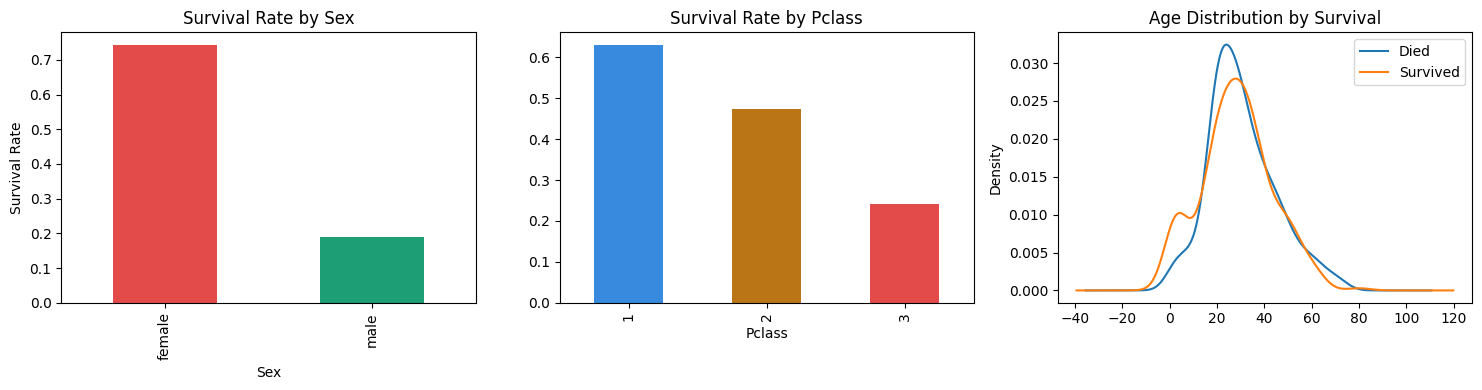

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

# Survival by Pclass
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['#378ADD', '#BA7517', '#E24B4A'])
axes[1].set_title('Survival Rate by Pclass')

# Age distribution by survival
df.groupby('Survived')['Age'].plot(kind='kde', ax=axes[2], legend=True)
axes[2].set_title('Age Distribution by Survival')
axes[2].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

EDA Checkpoint — Evidence Confirms Your Hypothesis
Read each plot yourself before I say anything:
Plot 1 — Survival by Sex:
Female survival rate ~74%. Male survival rate ~19%. Sex is the strongest predictor — confirmed. "Women first" wasn't just a policy — it's visible in the data.
Plot 2 — Survival by Pclass:
1st class ~63%, 2nd class ~47%, 3rd class ~25%. Clear descending pattern. Pclass is a strong predictor — confirmed.
Plot 3 — Age Distribution by Survival:
The orange (survived) line has a small bump around age 5–10 that the blue (died) line doesn't. Children had a slightly higher survival rate — confirmed. But the overall age distributions overlap heavily — Age is a weaker signal than Sex and Pclass.

Your pre-EDA hypothesis vs evidence:

| Feature | Your prediction | Evidence |
|---|---|---|
| Sex | ✅ Strong signal | ✅ Confirmed — strongest predictor |
| Age | ✅ Some signal | ✅ Confirmed — but weaker than expected |
| Pclass | ✅ Strong signal | ✅ Confirmed — clear linear pattern |

EDA complete. You know your data. Now build the pipeline.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1 — Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Step 2 — Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
# print(f"R²   : {r2_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



| Label | Mapping       |
|:------|:--------------|
| Survived | 1 (Positive) |
| Died    | 0 (Negative) |

So:

What is the lead metric for this use case? Think about the cost of FP vs FN:


FP = model predicted Survived, actually Died

FN = model predicted Died, actually Survived

<br>

**Now with that mapping clear — which error is more costly in this context, and what does that tell you about the lead metric?**

A person incorrectly declared dead faces catastrophic real-world consequences — frozen assets, cancelled insurance, legal complications. That's an unacceptable error.
FN = declaring a survivor dead = highest cost → Recall is the lead metric.


**For this use case FN is more costly and recall will be the lead metric**




**Build a custom passenger profile and predict survival**

In [20]:
import pandas as pd

custom_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 'female',
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7,
    'Embarked': 'S'
}])

prediction = pipeline.predict(custom_passenger)[0]
probability = pipeline.predict_proba(custom_passenger)[0]

print(f"Survived: {'Yes' if prediction == 1 else 'No'}")
print(f"Probability of survival: {probability[1]:.1%}")

Survived: Yes
Probability of survival: 60.0%


In [22]:
import pandas as pd

custom_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 'male',
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7,
    'Embarked': 'S'
}])

prediction = pipeline.predict(custom_passenger)[0]
probability = pipeline.predict_proba(custom_passenger)[0]

print(f"Survived: {'Yes' if prediction == 1 else 'No'}")
print(f"Probability of survival: {probability[1]:.1%}")

Survived: No
Probability of survival: 14.0%


In [ ]:
## Sample data
##Survived	Pclass	Sex	  Age	  SibSp	Parch	Fare	  Embarked
#0	3	male	22.0	1	0	7.2500	S

##Survived	Pclass	Sex	  Age	  SibSp	Parch	Fare	  Embarked
#0	        	3	    male	22.0	1	      0	  7.2500	S

Recall for Died (class 0) = 0.85
Out of all passengers who actually died — the model correctly identified 85% of them.
15% of people who died were incorrectly predicted as survivors — these are your FN for class 0.

Recall for Survived (class 1) = 0.74
Out of all passengers who actually survived — the model correctly identified 74% of them.
26% of people who actually survived were incorrectly predicted as dead — these are your FN for class 1.

What this means for your lead metric:
Your lead metric is Recall for the Survived class (class 1) = 0.74. That's the number you want to push higher — because those are the real people incorrectly declared dead.
26% of actual survivors being told they're dead is too high for a real-world system. That's your improvement target.

##Why is class 0 recall higher than class 1?

The model saw more "died" examples during training (62% of data). It got better at predicting death than survival — a direct consequence of the mild class imbalance.


**What would you try to fix this?**

**class_weight='balanced'**

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1 — Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Step 2 — Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Step 3 — Build numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step 4 — Build categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Step 5 — Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Step 6 — Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced'))
])

# Step 7 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8 — Train
pipeline.fit(X_train, y_train)

# Step 9 — Evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
# print(f"MAE  : {mean_absolute_error(y_test, y_pred):,.0f}")
# print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
# print(f"R²   : {r2_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Improvement Confirmed

| Metric | Without balanced | With balanced | Change |
|:---|:---|:---|:---|
| Accuracy | 0.80 | 0.82 | ✅ Better |
| Recall class 1 (survived) | 0.74 | 0.76 | ✅ Better |
| Precision class 1 | 0.77 | 0.80 | ✅ Better |
| F1 class 1 | 0.76 | 0.78 | ✅ Better |

Every metric improved. `class_weight='balanced'` helped the model pay more attention to the minority class (survived) without sacrificing performance on the majority class (died).

## How do we improve recall even better ?

Lever 1 — Lower the decision threshold
By default, the model predicts "survived" only when probability ≥ 50%. Lower that threshold — say to 35% — and more passengers get classified as survived. Recall goes up, but precision goes down. Classic trade-off.
pythony_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_prob >= 0.35).astype(int)



---


Lever 2 — Feature Engineering
Add a FamilySize feature:
pythondf['FamilySize'] = df['SibSp'] + df['Parch'] + 1
Travelling alone vs with family affected survival rates. New signal = better recall.


---


Lever 3 — Try a different model
Gradient Boosting (GradientBoostingClassifier) or XGBClassifier often outperform Random Forest on structured data like Titanic.


---


Lever 4 — Tune hyperparameters
Adjust n_estimators, max_depth, min_samples_split on Random Forest to reduce overfitting.


---


The trade-off to always remember:

Pushing recall higher always costs precision. Every lever that catches more survivors will also incorrectly flag more deaths as survivals.